<a href="https://colab.research.google.com/github/Anggardy/Item-Demand-Forecasting-Project/blob/main/itemDemand_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Akses Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("dhrubangtalukdar/store-item-demand-forecasting-dataset")

Using Colab cache for faster access to the 'store-item-demand-forecasting-dataset' dataset.


In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/store-item-demand-forecasting-dataset/retail_sales.csv')

In [ ]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


# Mengolah Data

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Membuat jumlah sales tiap date
df_agg = df.groupby('date')['sales'].sum().reset_index()

# Ekstraksi fitur
df_agg['tahun'] = df_agg['date'].dt.year
df_agg['bulan'] = df_agg['date'].dt.month
df_agg['hari'] = df_agg['date'].dt.day
df_agg['hari_dalam_minggu'] = df_agg['date'].dt.dayofweek

In [ ]:
df_agg.head()

,date,sales,tahun,bulan,hari,hari_dalam_minggu
0,2019-01-01,74119,2019,1,1,1
1,2019-01-02,77119,2019,1,2,2
2,2019-01-03,70810,2019,1,3,3
3,2019-01-04,59269,2019,1,4,4
4,2019-01-05,52621,2019,1,5,5


# Windowing

## Cek ACF & PCF untuk menentukan ukuran window

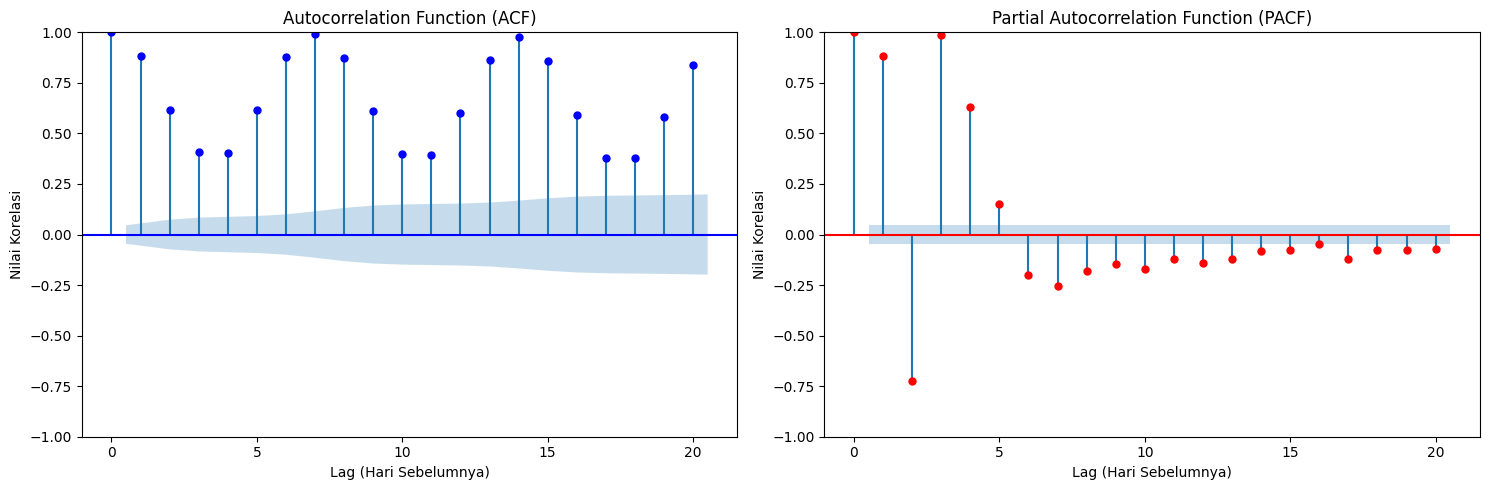

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot ACF
plot_acf(df_agg['sales'], lags=20, ax=axes[0], color='blue')
# lags=20 adalah batas acak untuk melihat jumlah lag pada beberapa hari ke belakang.
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (Hari Sebelumnya)')
axes[0].set_ylabel('Nilai Korelasi')

# Plot PACF
plot_pacf(df_agg['sales'], lags=20, ax=axes[1], color='red')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (Hari Sebelumnya)')
axes[1].set_ylabel('Nilai Korelasi')

plt.tight_layout()
plt.show()

## Proses Lag Window

In [ ]:
for i in range (1, 8):
  df_agg[f'sales_lag{i}'] = df_agg['sales'].shift(i)

In [ ]:
df_agg.head(10)

,date,sales,tahun,bulan,hari,hari_dalam_minggu,sales_lag1,sales_lag2,sales_lag3,sales_lag4,sales_lag5,sales_lag6,sales_lag7
0,2019-01-01,74119,2019,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,77119,2019,1,2,2,74119.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-03,70810,2019,1,3,3,77119.0,74119.0,NaN,NaN,NaN,NaN,NaN
3,2019-01-04,59269,2019,1,4,4,70810.0,77119.0,74119.0,NaN,NaN,NaN,NaN
4,2019-01-05,52621,2019,1,5,5,59269.0,70810.0,77119.0,74119.0,NaN,NaN,NaN
5,2019-01-06,55638,2019,1,6,6,52621.0,59269.0,70810.0,77119.0,74119.0,NaN,NaN
6,2019-01-07,66523,2019,1,7,0,55638.0,52621.0,59269.0,70810.0,77119.0,74119.0,NaN
7,2019-01-08,76810,2019,1,8,1,66523.0,55638.0,52621.0,59269.0,70810.0,77119.0,74119.0
8,2019-01-09,80146,2019,1,9,2,76810.0,66523.0,55638.0,52621.0,59269.0,70810.0,77119.0
9,2019-01-10,73115,2019,1,10,3,80146.0,76810.0,66523.0,55638.0,52621.0,59269.0,70810.0


In [ ]:
# Membuang baris kosong dan kolom 'date
df_model = df_agg.dropna().drop('date', axis=1)

In [ ]:
df_model.head()

,sales,tahun,bulan,hari,hari_dalam_minggu,sales_lag1,sales_lag2,sales_lag3,sales_lag4,sales_lag5,sales_lag6,sales_lag7
7,76810,2019,1,8,1,66523.0,55638.0,52621.0,59269.0,70810.0,77119.0,74119.0
8,80146,2019,1,9,2,76810.0,66523.0,55638.0,52621.0,59269.0,70810.0,77119.0
9,73115,2019,1,10,3,80146.0,76810.0,66523.0,55638.0,52621.0,59269.0,70810.0
10,61893,2019,1,11,4,73115.0,80146.0,76810.0,66523.0,55638.0,52621.0,59269.0
11,54760,2019,1,12,5,61893.0,73115.0,80146.0,76810.0,66523.0,55638.0,52621.0


## Split Data

In [ ]:
# Memisahkan fitur(X) dan Target(y)
X = df_model.drop('sales', axis=1)
y = df_model['sales']

# Train-Test Split berdasarkan jumlah hari per tahun
X_train = X.iloc[:-365]
y_train = y.iloc[:-365]
X_test = X.iloc[-365:]
y_test = y.iloc[-365:]

# Train Model

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# Prediksi

In [ ]:
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
print(f'MAE = {mae:.2f}')
print(f'MAPE = {mape}')

persentase_error = mape * 100
akurasi = 100 - persentase_error
print(f"Rata-rata Margin Kesalahan (MAPE): {persentase_error:.2f}")
print(f"Tingkat Akurasi Model XGBoost: {akurasi:.2f}%")

MAE = 764.16
MAPE = 0.008585401810705662
Rata-rata Margin Kesalahan (MAPE): 0.86
Tingkat Akurasi Model XGBoost: 99.14%


In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')

MSE: 1697084.0
RMSE: 1302.7218017578125


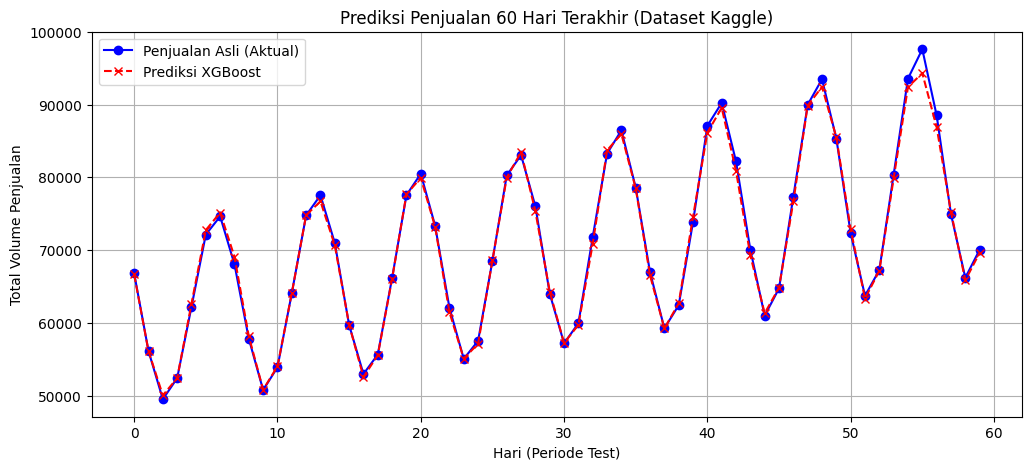

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[-60:], label='Penjualan Asli (Aktual)', marker='o', color='blue')
plt.plot(predictions[-60:], label='Prediksi XGBoost', marker='x', linestyle='--', color='red')
plt.title('Prediksi Penjualan 60 Hari Terakhir (Dataset Kaggle)')
plt.xlabel('Hari (Periode Test)')
plt.ylabel('Total Volume Penjualan')
plt.legend()
plt.grid(True)
plt.show()